# seq2ribo: Predict Ribosome Profiles from RNA Sequence

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kingsford-Group/seq2ribo/blob/main/notebooks/colab_seq2ribo.ipynb)

**seq2ribo** predicts where ribosomes sit on an mRNA transcript using only the RNA sequence as input. It combines a **structure-aware stochastic simulation (sTASEP)** of ribosome traffic with a **neural network polisher (Mamba)** to produce per-codon ribosome occupancy profiles, translation efficiency (TE) estimates, and protein expression predictions.

### Pipeline overview

```
RNA sequence
    │
    ├── ViennaRNA folding → secondary structure → per-codon geometry features
    │
    ├── sTASEP simulation  → physics-based ribosome occupancy estimate
    │
    └── Mamba polisher     → refined per-codon ribosome counts
                                │
                                ├── A-site profile (riboseq task)
                                ├── Translation efficiency (TE task)
                                └── Protein expression (protein task)
```

**Supported cell lines:** HEK293, LCL, RPE-1, iPSC

**Paper:** [bioRxiv](https://www.biorxiv.org/content/10.64898/2026.02.08.700508v2)  
**Repository:** [github.com/Kingsford-Group/seq2ribo](https://github.com/Kingsford-Group/seq2ribo)

---
## 0. Colab Environment Setup

This section installs all dependencies on the Colab GPU runtime. **Run each cell in order.** The Conda installation step will restart the runtime automatically — this is expected.

**Important:** After that restart, Google Colab usually **clears `/content`**. The next cells **re-clone** `seq2ribo` if needed, run **`conda install`** for ViennaRNA, then a separate **`pip`** cell for mamba-ssm and seq2ribo. If Colab warns that you must **restart** again after conda, do it and then run **only** the pip cell. You do not need to re-run the pre-restart `git clone` (it is harmless if you do).

In [1]:
# Verify GPU is available
!nvidia-smi
import torch
print(f"\nPyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Mon Apr  6 18:58:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

# Clone the repository (includes model weights). Re-run safe: skips if folder exists.
![ -d seq2ribo ] || git clone https://github.com/Kingsford-Group/seq2ribo.git
%cd seq2ribo

Cloning into 'seq2ribo'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 158 (delta 32), reused 53 (delta 21), pack-reused 86 (from 2)
Receiving objects: 100% (158/158), 107.52 MiB | 23.25 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/seq2ribo


In [3]:
# Install Conda in Colab (this will RESTART the runtime — that is normal)
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


> **After the condacolab runtime restarts**, continue from the **clone + conda** cell below (not from the very top).
>
> **Yellow “Restart session” after `conda install`?** Colab may say numpy/matplotlib/PIL were already imported and you must restart. That is normal: `conda` updated libraries on disk while the kernel still had old copies in memory. Use **Runtime → Restart session** once, then run **only** the **pip / mamba-ssm** cell (skip the conda cell). `/content/seq2ribo` stays on disk.

In [1]:
# After condacolab restart, /content is often empty — re-clone before installing.
import os
import shutil
import subprocess

REPO = "/content/seq2ribo"
os.makedirs("/content", exist_ok=True)
if os.path.isdir(REPO) and not os.path.isdir(os.path.join(REPO, ".git")):
    shutil.rmtree(REPO)
if not os.path.isdir(REPO):
    print("Cloning seq2ribo (fresh runtime — expected after restart)...")
    subprocess.run(
        ["git", "clone", "https://github.com/Kingsford-Group/seq2ribo.git", REPO],
        check=True,
    )
else:
    print(f"Using existing repo: {REPO}")

%cd /content/seq2ribo

# ViennaRNA → `import RNA`. --freeze-installed avoids upgrading NumPy/Matplotlib
# that Colab may have already imported (reduces "you must restart" warnings).
# If the solver errors, remove --freeze-installed and restart the runtime if prompted.
!conda install -y -c conda-forge -c bioconda viennarna --freeze-installed

print("\nConda step done. Run the next cell for pip (mamba-ssm + seq2ribo).")
print("If Colab asks you to restart, do that first, then skip this cell and run pip only.")

Using existing repo: /content/seq2ribo
/content/seq2ribo
Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - viennarna


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    gmp-6.3.0                  |       hac33072_2         449 KB  conda-forge
    gsl-2.7                    |       he838d99_0         3.2 MB  conda-forge
    libblas-3.9.0              |31_h59b9bed_openblas          16 KB  conda-forge
    libcblas-3.9.0             |31_he106b2a_openblas          16 KB  conda-forge
    libgfortran-14.2.0         |       h69a702a_2    

### Pip install (mamba-ssm + seq2ribo)

Run this **after** the conda cell. If you used **Runtime → Restart session** because of the PIL/numpy warning, **do not** re-run the conda cell — go straight to this one. It starts with `%cd` so it works in a fresh session.

**mamba-ssm:** PyPI only ships source; building on Colab usually fails. This cell picks **matching pre-built wheels** from the official GitHub releases (same CUDA / PyTorch / Python as your runtime), then `pip install -e .` for seq2ribo.

In [2]:
%cd /content/seq2ribo

import subprocess
import sys

# Upgrade pip tooling (helps wheel installs)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-U", "pip", "setuptools", "wheel"]
)

import torch


def _install_mamba_from_github_wheels():
    """Colab: PyPI mamba-ssm almost always fails to build; use release wheels."""
    v = sys.version_info
    cp = f"cp{v.major}{v.minor}"
    raw_tv = torch.__version__.split("+")[0]
    t_maj_s, t_min_s = raw_tv.split(".")[:2]
    t_maj, t_min = int(t_maj_s), int(t_min_s)
    cuda = torch.version.cuda or "12.0"
    cu_major = int(str(cuda).split(".")[0])

    print(f"Detected torch={torch.__version__}, torch.version.cuda={torch.version.cuda}, {cp}")

    causal_base = "https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.6.1.post4/"
    mamba_base = "https://github.com/state-spaces/mamba/releases/download/v2.3.1/"

    if cu_major >= 13:
        cuda_opts = [cu_major, 12]
    elif cu_major == 12:
        cuda_opts = [12, 13]
    else:
        cuda_opts = [cu_major]

    torch_opts = [f"{t_maj}.{t_min - d}" for d in range(0, 8) if t_min - d >= 6]
    if not torch_opts:
        torch_opts = ["2.10", "2.9", "2.8", "2.7", "2.6"]
    abis = ("TRUE", "FALSE")

    for cu in cuda_opts:
        cut = f"cu{cu}"
        for tt in torch_opts:
            ttag = f"torch{tt}"
            for abi in abis:
                c_whl = (
                    f"causal_conv1d-1.6.1+{cut}{ttag}cxx11abi{abi}-"
                    f"{cp}-{cp}-linux_x86_64.whl"
                )
                m_whl = (
                    f"mamba_ssm-2.3.1+{cut}{ttag}cxx11abi{abi}-"
                    f"{cp}-{cp}-linux_x86_64.whl"
                )
                c_url = causal_base + c_whl
                m_url = mamba_base + m_whl
                print("Trying:", m_whl[:72], "...")
                r = subprocess.run(
                    [sys.executable, "-m", "pip", "install", "-q", c_url, m_url],
                    capture_output=True,
                    text=True,
                )
                if r.returncode == 0:
                    print("Installed causal-conv1d + mamba-ssm from GitHub wheels.")
                    return
    print("No matching wheels; falling back to source build (slow, may fail)...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "packaging", "ninja"]
    )
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-build-isolation",
            "causal-conv1d",
            "mamba-ssm",
        ]
    )


_install_mamba_from_github_wheels()
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "."])

print("\nPip install complete. Run the next cell to verify imports.")

/content/seq2ribo
Detected torch=2.10.0+cu128, torch.version.cuda=12.8, cp312
Trying: mamba_ssm-2.3.1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl ...
Installed causal-conv1d + mamba-ssm from GitHub wheels.

Pip install complete. Run the next cell to verify imports.


In [3]:
# Verify all imports work (run after the pip cell; %cd not required if you already ran it)
%cd /content/seq2ribo

import subprocess
import sys

try:
    import RNA
except ModuleNotFoundError:
    print("ViennaRNA not on PYTHONPATH after conda; installing PyPI wheel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ViennaRNA"])
    import RNA  # noqa: F401

import mamba_ssm
from seq2ribo import Seq2Ribo

print("All imports OK!")

/content/seq2ribo
ViennaRNA not on PYTHONPATH after conda; installing PyPI wheel...
All imports OK!


---
## 1. Setup

Import libraries and initialize the predictor.

In [4]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from seq2ribo import Seq2Ribo

WEIGHTS_DIR = "weights"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.figsize": (12, 4),
})

COLORS = {
    "ground_truth": "#2d2d2d",
    "stasep": "#3b82f6",
    "polisher": "#ef4444",
    "polisher_fill": "#fca5a5",
    "stasep_fill": "#93c5fd",
}

print("Setup complete.")

Setup complete.


In [5]:
# Load sample test-set transcripts (real ribo-seq data)
with open("notebooks/sample_data/demo_transcripts.pkl", "rb") as f:
    demo_data = pickle.load(f)

print(f"Loaded {len(demo_data)} demo transcripts:")
for key in sorted(demo_data.keys()):
    d = demo_data[key]
    n_codons = len(d["sequence"]) // 3
    print(f"  {d['cell_line']:5s}  {d['tx_id']:25s}  {n_codons:4d} codons")

mrfp_expr_df = pd.read_csv("notebooks/sample_data/mrfp_expr_test_samples.csv")
mrfp_expr_demo_seq = mrfp_expr_df.iloc[0]["Sequence"]
mrfp_expr_demo_label = "mRFP test variant (row 0)"

Loaded 6 demo transcripts:
  ipsc   ENST00000367883.3           167 codons
  ipsc   ENST00000572154.1            40 codons
  ipsc   ENST00000649490.1           325 codons
  lcl    ENST00000521529.5            41 codons
  lcl    ENST00000594523.5           114 codons
  lcl    ENST00000679472.1           207 codons


---
## 2. Ribosome A-site Profile Prediction

The core task: given an mRNA coding sequence, predict the per-codon ribosome occupancy (A-site profile).

We compare three signals:
- **Ground truth** — experimentally measured A-site counts from ribo-seq
- **sTASEP only** — physics-based simulation without neural refinement
- **sTASEP + Polisher** — simulation refined by the Mamba neural network

In [6]:
predictor_ipsc = Seq2Ribo(cell_line="ipsc", weights_dir=WEIGHTS_DIR)

In [7]:
sample = demo_data[("ipsc", "ENST00000367883.3")]
seq = sample["sequence"]
demo_cds_seq = seq
demo_n_codons = len(seq) // 3
n_codons = demo_n_codons

gt_asite_nuc = sample["asite_counts"]
gt_asite = gt_asite_nuc.reshape(-1, 3).sum(axis=1).astype(np.float64)

print(f"Transcript: {sample['tx_id']}")
print(f"Length: {n_codons} codons ({len(seq)} nt)")
print(f"Total A-site reads: {int(gt_asite.sum())}")

Transcript: ENST00000367883.3
Length: 167 codons (501 nt)
Total A-site reads: 14746


In [8]:
pred_stasep = predictor_ipsc.predict(
    demo_cds_seq, task="riboseq", use_polisher=False, n_stasep_runs=50
)[0]

pred_polished = predictor_ipsc.predict(
    demo_cds_seq, task="riboseq", use_polisher=True, n_stasep_runs=50
)[0]

print(f"sTASEP prediction shape: {pred_stasep.shape}")
print(f"Polished prediction shape: {pred_polished.shape}")

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_final_unscaled.pt...
sTASEP prediction shape: (167,)
Polished prediction shape: (167,)


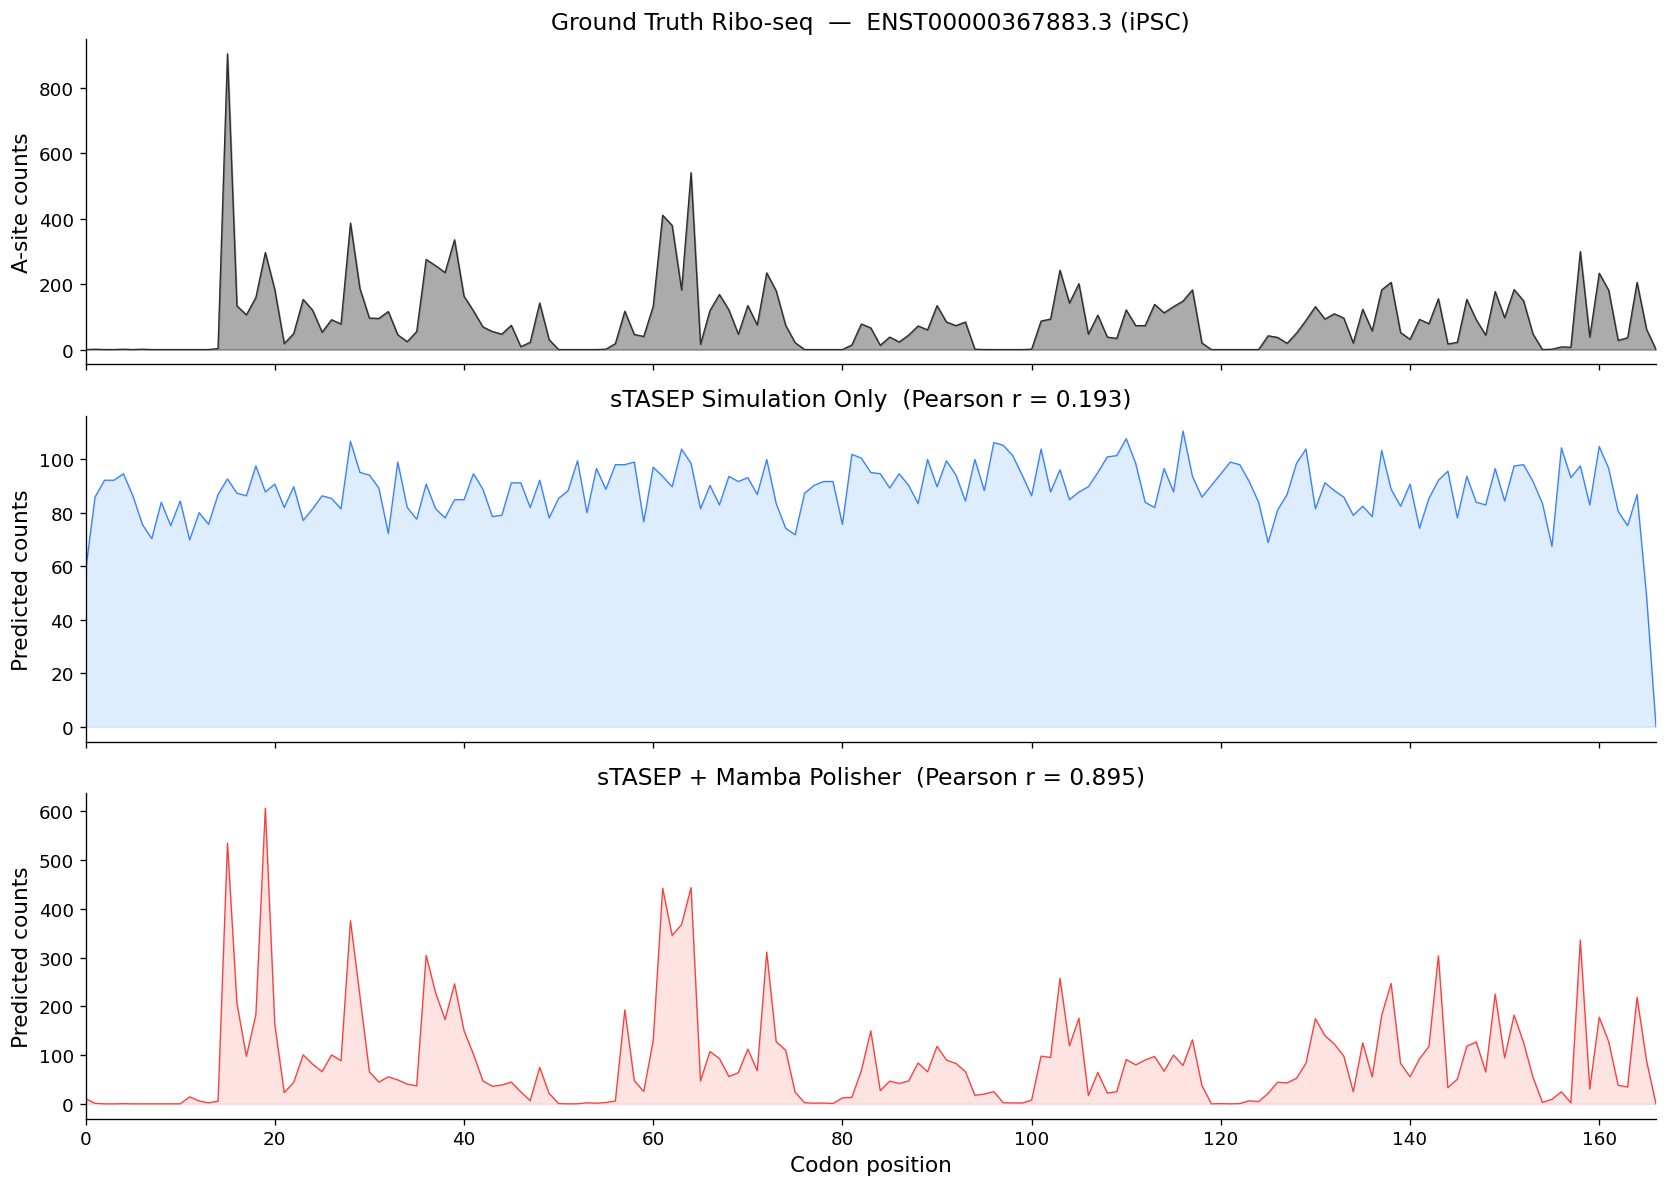

In [9]:
gt_total = gt_asite.sum()
stasep_scaled = pred_stasep * (gt_total / (pred_stasep.sum() + 1e-9))
polished_scaled = pred_polished * (gt_total / (pred_polished.sum() + 1e-9))

x = np.arange(n_codons)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].fill_between(x, gt_asite, alpha=0.4, color=COLORS["ground_truth"])
axes[0].plot(x, gt_asite, color=COLORS["ground_truth"], linewidth=0.8)
axes[0].set_ylabel("A-site counts")
axes[0].set_title(f"Ground Truth Ribo-seq  —  {sample['tx_id']} (iPSC)")

axes[1].fill_between(x, stasep_scaled, alpha=0.3, color=COLORS["stasep_fill"])
axes[1].plot(x, stasep_scaled, color=COLORS["stasep"], linewidth=0.8)
r_st, _ = pearsonr(gt_asite, stasep_scaled)
axes[1].set_ylabel("Predicted counts")
axes[1].set_title(f"sTASEP Simulation Only  (Pearson r = {r_st:.3f})")

axes[2].fill_between(x, polished_scaled, alpha=0.3, color=COLORS["polisher_fill"])
axes[2].plot(x, polished_scaled, color=COLORS["polisher"], linewidth=0.8)
r_pol, _ = pearsonr(gt_asite, polished_scaled)
axes[2].set_ylabel("Predicted counts")
axes[2].set_title(f"sTASEP + Mamba Polisher  (Pearson r = {r_pol:.3f})")
axes[2].set_xlabel("Codon position")

for ax in axes:
    ax.set_xlim(0, n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

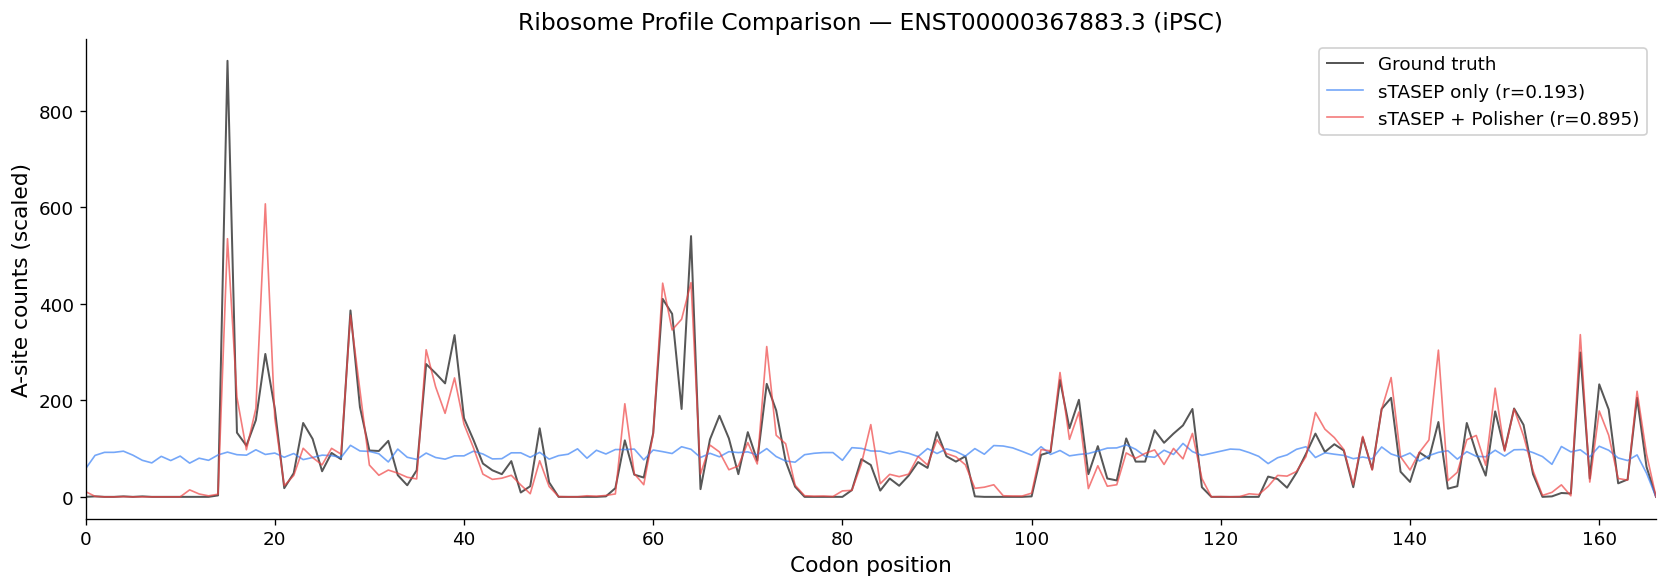

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, gt_asite, color=COLORS["ground_truth"], linewidth=1.2, label="Ground truth", alpha=0.8)
ax.plot(x, stasep_scaled, color=COLORS["stasep"], linewidth=1.0, label=f"sTASEP only (r={r_st:.3f})", alpha=0.7)
ax.plot(x, polished_scaled, color=COLORS["polisher"], linewidth=1.0, label=f"sTASEP + Polisher (r={r_pol:.3f})", alpha=0.7)

ax.set_xlabel("Codon position")
ax.set_ylabel("A-site counts (scaled)")
ax.set_title(f"Ribosome Profile Comparison — {sample['tx_id']} (iPSC)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(0, n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 3. Cross-cell-line Comparison (All 4 Cell Lines)

The same gene can show different ribosome occupancy patterns across cell types due to differences in tRNA availability, codon usage bias, and regulatory context. seq2ribo captures this through cell-line-specific sTASEP rate parameters.

Here we run the **same transcript through all four cell lines** (HEK293, LCL, RPE-1, iPSC) and visualize the differences side by side.

In this panel, **ribosome profiles, TE, and protein expression** all use the same ribo-seq demo transcript (`sample['cds_seq']`) for direct cross-cell-line comparison. Each line is a **separately trained** checkpoint, and raw expression values are **not** directly comparable across lines; the protein panel uses a **log-scaled** y-axis.

In [11]:
# Initialize predictors for all four cell lines
all_cell_lines = ["ipsc", "lcl", "hek293", "rpe"]
predictors = {}
for cl in all_cell_lines:
    predictors[cl] = Seq2Ribo(cell_line=cl, weights_dir=WEIGHTS_DIR)
predictor_lcl = predictors["lcl"]

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: lcl)...
Loading weights from weights/lcl_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: hek293)...
Loading weights from weights/hek293_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: rpe)...
Loading weights from weights/rpe_mamba_final_unscaled.pt...


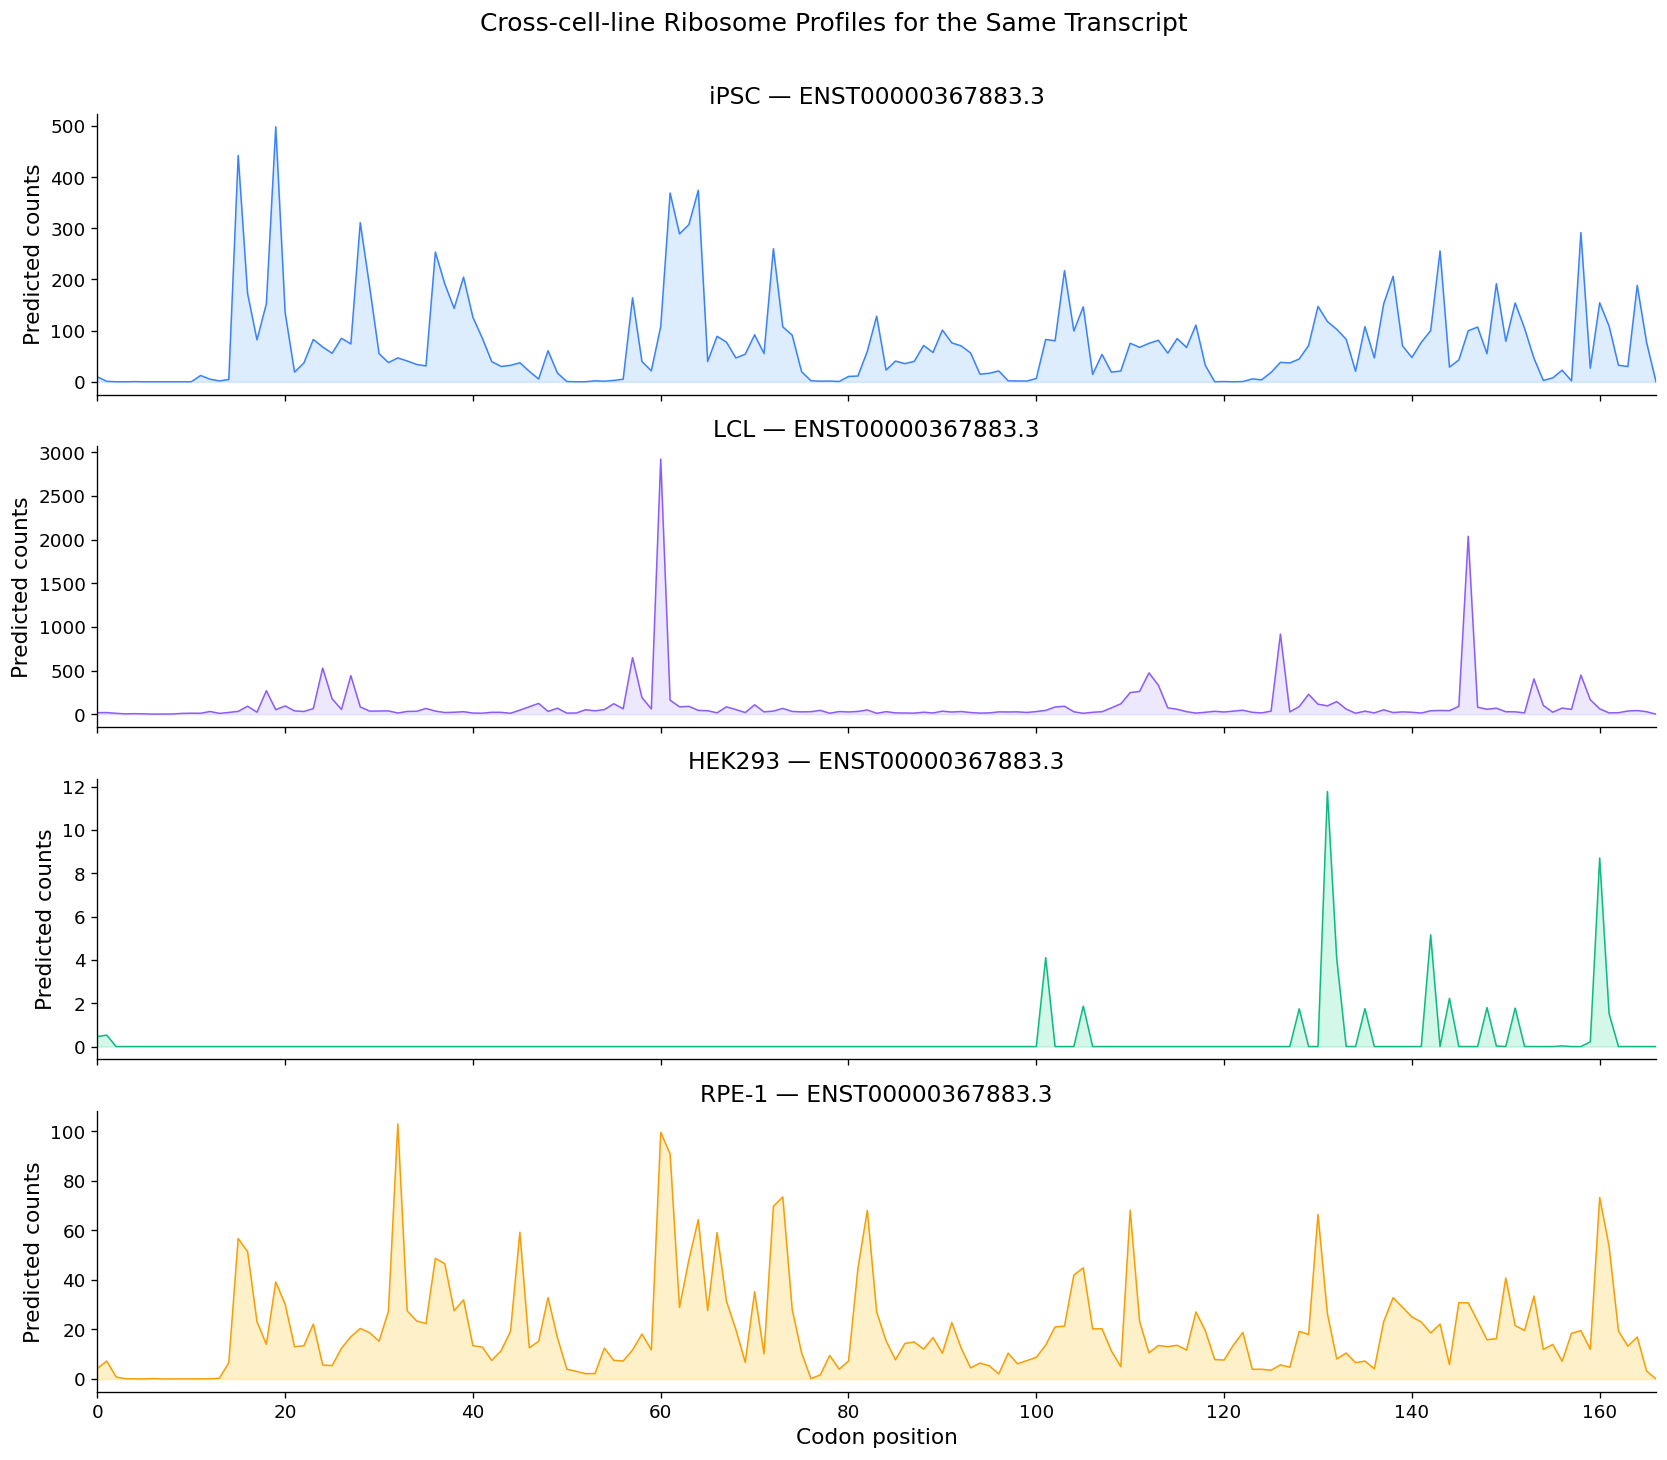

In [12]:
# Predict A-site profiles for the same transcript across all 4 cell lines
cell_preds = {}
for cl in all_cell_lines:
    cell_preds[cl] = predictors[cl].predict(
        demo_cds_seq, task="riboseq", use_polisher=True, n_stasep_runs=50
    )[0]

cell_colors = {
    "ipsc":   ("#3b82f6", "#93c5fd"),
    "lcl":    ("#8b5cf6", "#c4b5fd"),
    "hek293": ("#10b981", "#6ee7b7"),
    "rpe":    ("#f59e0b", "#fcd34d"),
}
cell_labels = {"ipsc": "iPSC", "lcl": "LCL", "hek293": "HEK293", "rpe": "RPE-1"}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, cl in zip(axes, all_cell_lines):
    pred = cell_preds[cl]
    color, fill = cell_colors[cl]
    ax.fill_between(x, pred, alpha=0.3, color=fill)
    ax.plot(x, pred, color=color, linewidth=0.9)
    ax.set_ylabel("Predicted counts")
    ax.set_title(f"{cell_labels[cl]} — {sample['tx_id']}")
    ax.set_xlim(0, n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Codon position")
fig.suptitle("Cross-cell-line Ribosome Profiles for the Same Transcript", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

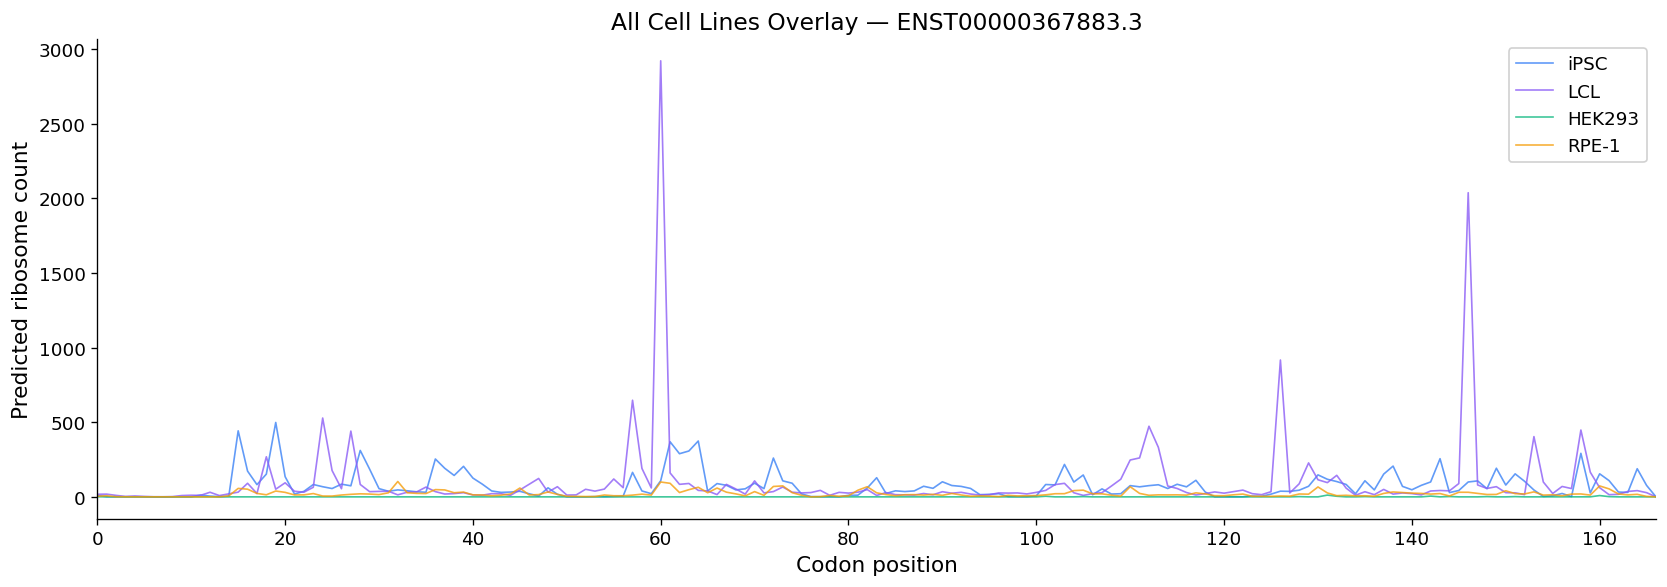

In [13]:
# Overlay all 4 cell lines on a single plot
fig, ax = plt.subplots(figsize=(14, 5))
for cl in all_cell_lines:
    color, _ = cell_colors[cl]
    ax.plot(x, cell_preds[cl], color=color, linewidth=1.0,
            label=cell_labels[cl], alpha=0.8)
ax.set_xlabel("Codon position")
ax.set_ylabel("Predicted ribosome count")
ax.set_title(f"All Cell Lines Overlay — {sample['tx_id']}")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(0, n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_expr_full_final.pt...
Inferred expression head hidden size: 128
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: lcl, use_utr=False)...
Loading weights from weights/lcl_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: lcl)...
Loading weights from weights/lcl_mamba_expr_full_final.pt...
Inferred expression head hidden size: 128
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading

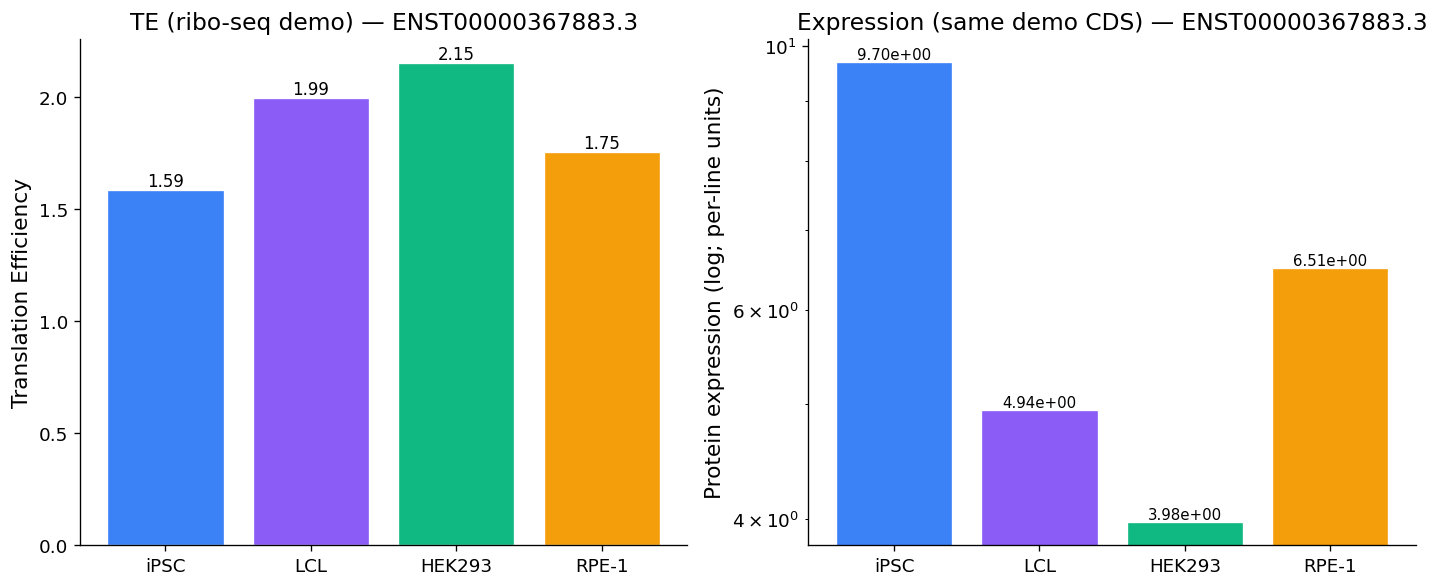

In [14]:
# TE + protein: same ribo-seq demo CDS sample for cross-cell-line comparison.
cell_te = {}
cell_expr = {}
for cl in all_cell_lines:
    cell_te[cl] = predictors[cl].predict(demo_cds_seq, task="te", n_stasep_runs=50)[0]
    cell_expr[cl] = predictors[cl].predict(demo_cds_seq, task="protein", n_stasep_runs=50)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels = [cell_labels[cl] for cl in all_cell_lines]
te_vals = [cell_te[cl] for cl in all_cell_lines]
expr_vals = [cell_expr[cl] for cl in all_cell_lines]
bar_colors = [cell_colors[cl][0] for cl in all_cell_lines]

bars1 = ax1.bar(labels, te_vals, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars1, te_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("Translation Efficiency")
ax1.set_title(f"TE (ribo-seq demo) — {sample['tx_id']}")
ax1.spines[["top", "right"]].set_visible(False)

bars2 = ax2.bar(labels, expr_vals, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars2, expr_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2e}", ha="center", va="bottom", fontsize=9)
ax2.set_yscale("log")
ax2.set_ylabel("Protein expression (log; per-line units)")
ax2.set_title(f"Expression (same demo CDS) — {sample['tx_id']}")
ax2.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 4. Translation Efficiency (TE) — CDS Only

Translation efficiency measures how effectively an mRNA is translated into protein, relative to its abundance. seq2ribo predicts TE as a scalar value from the coding sequence (CDS).

The model outputs a value in [0, 1] which is then inverse-transformed back to the original TE scale.

In [15]:
ipsc_transcripts = [
    demo_data[k] for k in sorted(demo_data.keys()) if k[0] == "ipsc"
]
tx_names = [d["tx_id"] for d in ipsc_transcripts]
tx_seqs = [d["sequence"] for d in ipsc_transcripts]
short_names = [n.split(".")[0].replace("ENST", "") for n in tx_names]

te_values = predictor_ipsc.predict(tx_seqs, task="te", n_stasep_runs=50)
te_scaled = predictor_ipsc.predict(tx_seqs, task="te", n_stasep_runs=50, return_scaled_te=True)

print(f"{'Transcript':<28s} {'TE (original scale)':>20s} {'TE (scaled 0-1)':>18s}")
print("-" * 70)
for name, te, te_s in zip(tx_names, te_values, te_scaled):
    print(f"{name:<28s} {te:>20.4f} {te_s:>18.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Transcript                    TE (original scale)    TE (scaled 0-1)
----------------------------------------------------------------------
ENST00000367883.3                          1.3453             0.6496
ENST00000572154.1                          1.5890             0.6894
ENST00000649490.1                          1.9795             0.7548


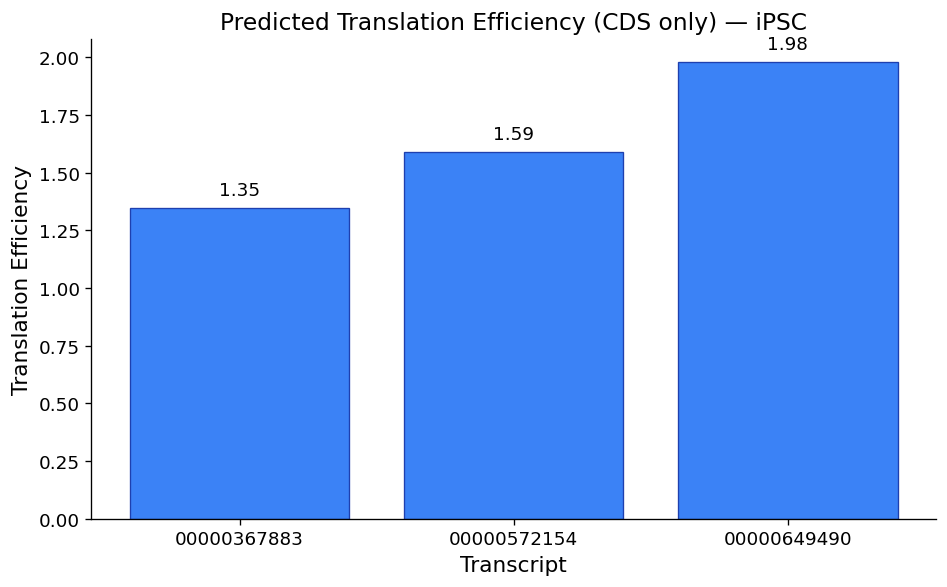

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(short_names, te_values, color="#3b82f6", edgecolor="#1e40af", linewidth=0.8)

for bar, val in zip(bars, te_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02 * max(te_values),
            f"{val:.2f}", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Transcript")
ax.set_ylabel("Translation Efficiency")
ax.set_title("Predicted Translation Efficiency (CDS only) — iPSC")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 5. Translation Efficiency (TE) — CDS + UTR Context

UTR sequences (5′ and 3′ untranslated regions) influence translation initiation and stability. seq2ribo can incorporate UTR context for a more complete TE prediction.

In UTR-aware mode, you provide the 5′ UTR, CDS, and 3′ UTR as separate inputs.

In [17]:
utr5_seqs = [
    "GCUCUCCGACUCCGGCGCGGCGCCCCGACUCCGGUACAGCCGUUCCGCCCACGCUCCGAC",
    "AGACCUGGCUGCUCUGAACAGCUCCGGCCUUA",
    "CCCGCCGGAGCCAUGUCUAUCAUGC",
]
cds_seqs = [d["sequence"] for d in ipsc_transcripts]
utr3_seqs = [
    "CCAGCUCCUGGUACCCUGGCACCUGUAAUAAUUUGUGUUCCUUCUAAAAGGUAAA",
    "UUAUCUAAAUUGUACAAAGGUAAUAAACUGUUGUUUCUAAUAAAUACAGACUAUUU",
    "CCUAAUAAAGAUCACUUUUAUAUCAAAUGUUUCA",
]

te_cds = predictor_ipsc.predict(cds_seqs, task="te", n_stasep_runs=50)

te_utr = predictor_ipsc.predict(
    task="te", use_utr=True,
    utr5_list=utr5_seqs, cds_list=cds_seqs, utr3_list=utr3_seqs,
    n_stasep_runs=50,
)

print(f"{'Transcript':<28s} {'TE (CDS)':>12s} {'TE (CDS+UTR)':>14s}")
print("-" * 58)
for name, t_cds, t_utr in zip(tx_names, te_cds, te_utr):
    print(f"{name:<28s} {t_cds:>12.4f} {t_utr:>14.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=True)...
Loading weights from weights/ipsc_mamba_te_utr_final.pt...
Transcript                       TE (CDS)   TE (CDS+UTR)
----------------------------------------------------------
ENST00000367883.3                  1.3413         1.5569
ENST00000572154.1                  1.5862         2.0327
ENST00000649490.1                  1.9935         1.3854


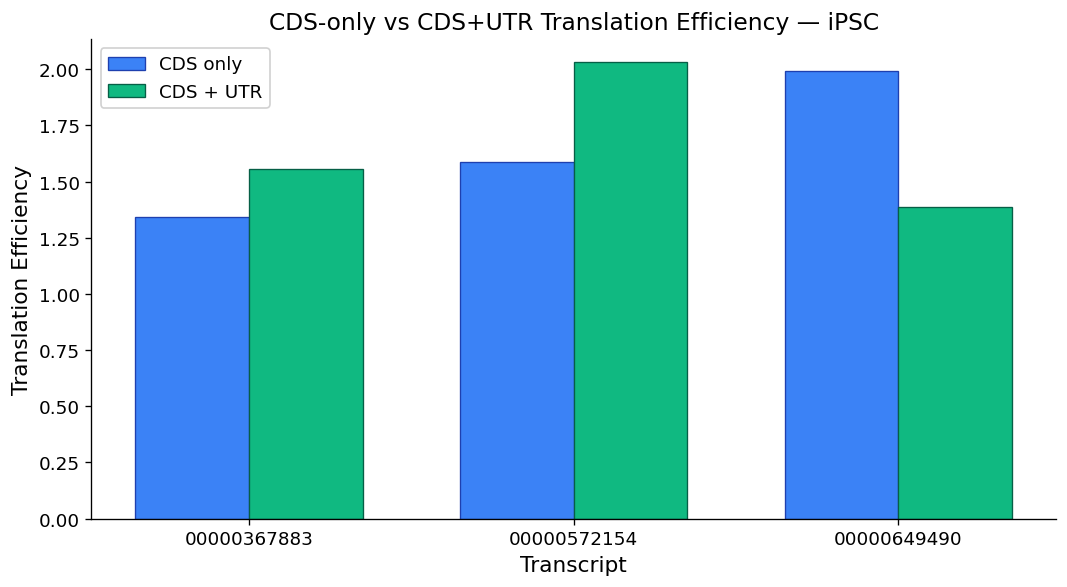

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

bar_width = 0.35
indices = np.arange(len(tx_names))

ax.bar(indices - bar_width / 2, te_cds, bar_width, label="CDS only",
       color="#3b82f6", edgecolor="#1e40af", linewidth=0.8)
ax.bar(indices + bar_width / 2, te_utr, bar_width, label="CDS + UTR",
       color="#10b981", edgecolor="#065f46", linewidth=0.8)

ax.set_xticks(indices)
ax.set_xticklabels(short_names)
ax.set_xlabel("Transcript")
ax.set_ylabel("Translation Efficiency")
ax.set_title("CDS-only vs CDS+UTR Translation Efficiency — iPSC")
ax.legend(framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 6. Protein Expression Prediction

The **protein-expression** checkpoints were trained on **mRFP fluorescent reporter** data (CDS variants), not ribo-seq. Predictions below use **held-out test** sequences from `notebooks/sample_data/mrfp_expr_test_samples.csv`.

Inference uses **Monte Carlo dropout** (32 stochastic forward passes). Outputs are **model-specific units**; do not compare raw values across cell-line checkpoints—only within one trained model.

In [19]:
mrfp_expr_names = [f"mRFP-test-{i}" for i in range(len(mrfp_expr_df))]
mrfp_expr_seqs = mrfp_expr_df["Sequence"].tolist()
expr_values = predictor_ipsc.predict(mrfp_expr_seqs, task="protein", n_stasep_runs=50)

print(f"{'mRFP variant':<28s} {'Protein Expression':>20s}")
print("-" * 50)
for name, expr in zip(mrfp_expr_names, expr_values):
    print(f"{name:<28s} {expr:>20.4f}")

Running sTASEP simulation for 6 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_expr_full_final.pt...
Inferred expression head hidden size: 128
mRFP variant                   Protein Expression
--------------------------------------------------
mRFP-test-0                                8.8392
mRFP-test-1                               10.0414
mRFP-test-2                               10.5197
mRFP-test-3                               10.6605
mRFP-test-4                                8.6899
mRFP-test-5                               11.0355


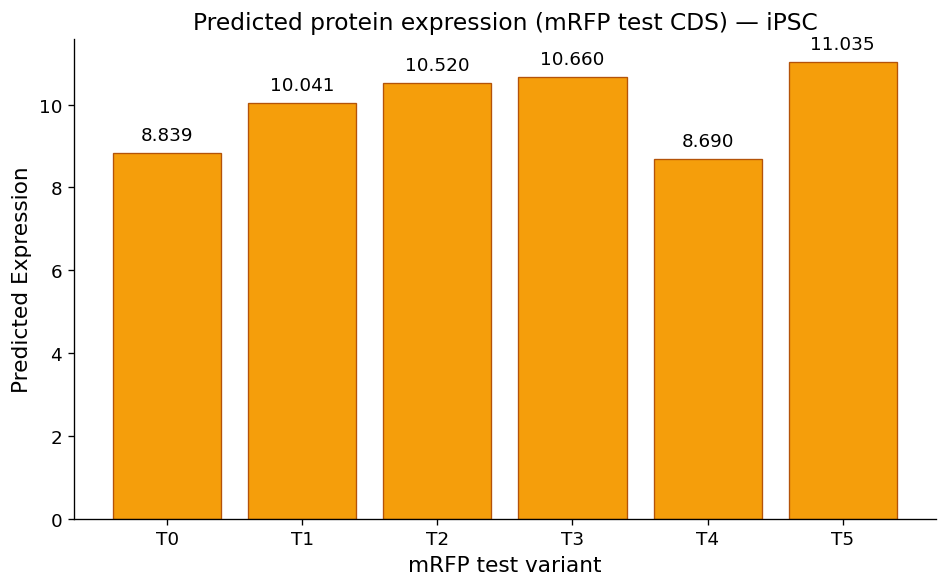

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

mrfp_short = [f"T{i}" for i in range(len(mrfp_expr_df))]
bars = ax.bar(mrfp_short, expr_values, color="#f59e0b", edgecolor="#b45309", linewidth=0.8)

for bar, val in zip(bars, expr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02 * max(expr_values),
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("mRFP test variant")
ax.set_ylabel("Predicted Expression")
ax.set_title("Predicted protein expression (mRFP test CDS) — iPSC")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---
## 7. Paste Your Own RNA Sequence

Replace the sequence below with your own RNA coding sequence (CDS). The sequence must:
- Start with a start codon (AUG)
- End with a stop codon (UAA, UAG, or UGA)
- Have a length that is a multiple of 3 (complete codons)
- Use RNA alphabet (A, U, G, C) — T is automatically converted to U

In [21]:
# ============================================================
# PASTE YOUR RNA CDS SEQUENCE HERE
# ============================================================
my_sequence = (
    "AUGGCCAAGCUGAAGAAGGCCACCUUCGGCUUCAGCGAGGGCACCAAGGUGCUGUUCC"
    "AGCCAUCCAUGUCCGUGUCCUUCGACAAGUUCGAGAAGGACGGCGACAUGGCCAUGGA"
    "GUCCCUGAAGGCCAUCUGCACCGACAACUUCUCCUGGAACCACCUGGUGGAGCUGCAC"
    "GGCAAGCAGGAGUUCGAGAGCAUGGGCGCCGACUGGAAUAACAUUGCUAAGAUCAUCU"
    "UCGAGGGCCUCGGCUUCAAGAAGGACGGCAACCCAAUCCCCAACCCAGAGCUCAAGGCC"
    "AUCGGCAAGAAGGUGGGCCCUGACAACGACCAGUAA"
)

cell_line = "ipsc"  # Change to: "hek293", "lcl", "rpe", or "ipsc"
# ============================================================

predictor = Seq2Ribo(cell_line=cell_line, weights_dir=WEIGHTS_DIR)

profile_stasep = predictor.predict(my_sequence, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]
profile_polished = predictor.predict(my_sequence, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]
te_value = predictor.predict(my_sequence, task="te", n_stasep_runs=50)[0]
expr_value = predictor.predict(my_sequence, task="protein", n_stasep_runs=50)[0]

n_cod = len(my_sequence.replace("T", "U").replace("t", "u")) // 3
print(f"Sequence length: {n_cod} codons")
print(f"Translation Efficiency: {te_value:.4f}")
print(f"Protein Expression:     {expr_value:.4f}")

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'riboseq' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_final_unscaled.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'te' (Cell Line: ipsc, use_utr=False)...
Loading weights from weights/ipsc_mamba_te_full_final_cds.pt...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Loading model for task 'protein' (Cell Line: ipsc)...
Loading weights from weights/ipsc_mamba_expr_full_final.pt...
Inferred expression head hidden size: 128
Sequence length: 109 codons
Translation Efficiency: 1.9285
Protein Expression:     9.6119


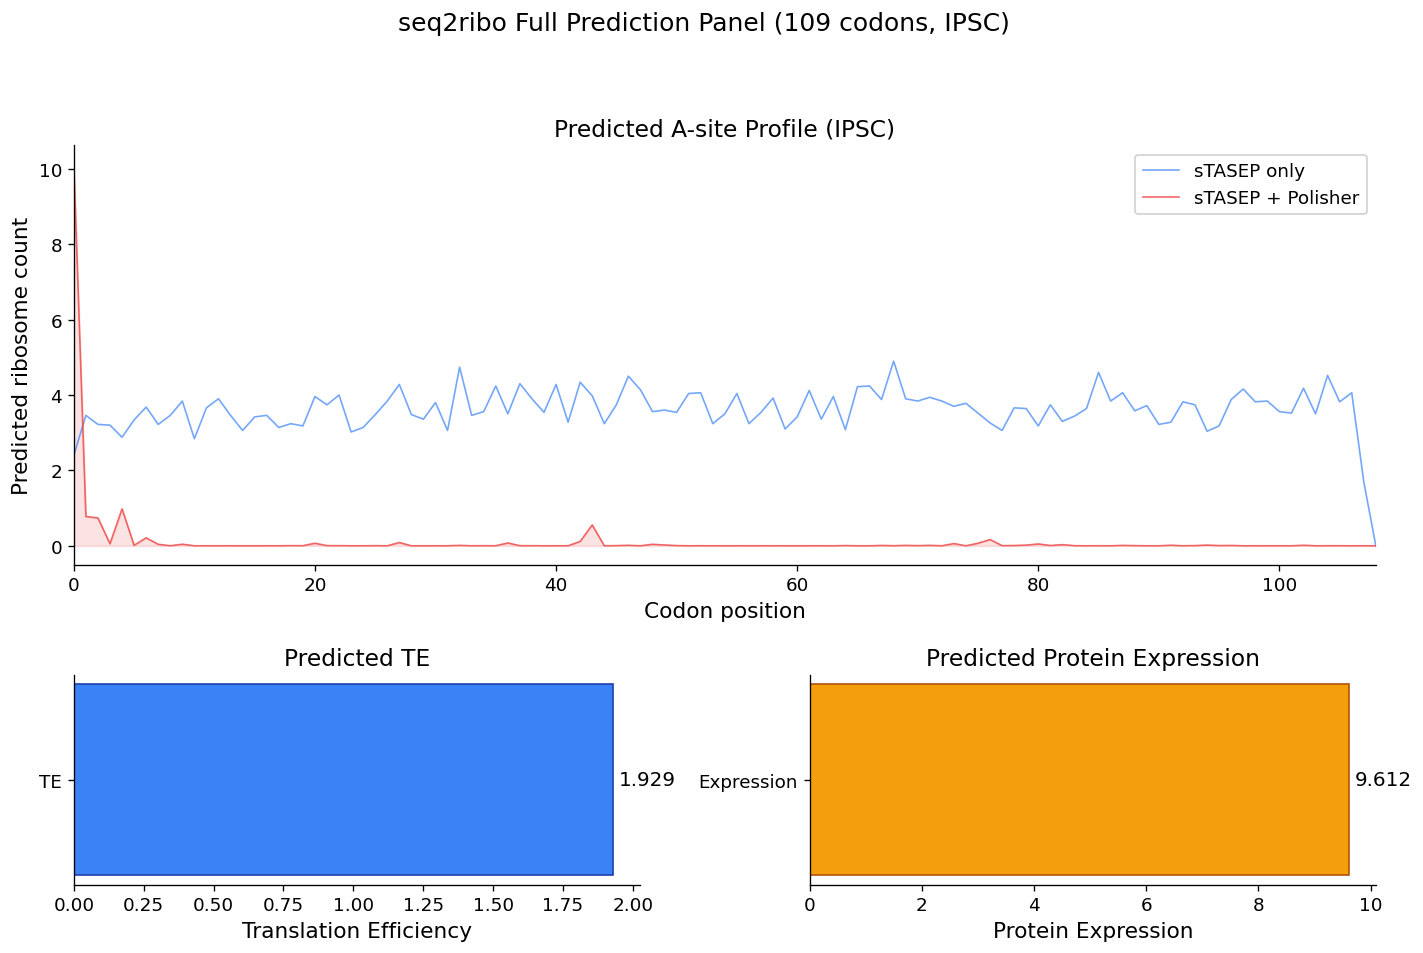

In [22]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.3)

ax_profile = fig.add_subplot(gs[0, :])
xp = np.arange(n_cod)
ax_profile.plot(xp, profile_stasep, color=COLORS["stasep"], linewidth=1.0, label="sTASEP only", alpha=0.7)
ax_profile.plot(xp, profile_polished, color=COLORS["polisher"], linewidth=1.0, label="sTASEP + Polisher", alpha=0.8)
ax_profile.fill_between(xp, profile_polished, alpha=0.15, color=COLORS["polisher"])
ax_profile.set_xlabel("Codon position")
ax_profile.set_ylabel("Predicted ribosome count")
ax_profile.set_title(f"Predicted A-site Profile ({cell_line.upper()})")
ax_profile.legend(loc="upper right", framealpha=0.9)
ax_profile.set_xlim(0, n_cod - 1)
ax_profile.spines[["top", "right"]].set_visible(False)

ax_te = fig.add_subplot(gs[1, 0])
ax_te.barh(["TE"], [te_value], color="#3b82f6", edgecolor="#1e40af", height=0.5)
ax_te.set_xlabel("Translation Efficiency")
ax_te.set_title("Predicted TE")
ax_te.text(te_value + 0.01 * abs(te_value), 0, f"{te_value:.3f}", va="center", fontsize=12)
ax_te.spines[["top", "right"]].set_visible(False)

ax_expr = fig.add_subplot(gs[1, 1])
ax_expr.barh(["Expression"], [expr_value], color="#f59e0b", edgecolor="#b45309", height=0.5)
ax_expr.set_xlabel("Protein Expression")
ax_expr.set_title("Predicted Protein Expression")
ax_expr.text(expr_value + 0.01 * abs(expr_value), 0, f"{expr_value:.3f}", va="center", fontsize=12)
ax_expr.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"seq2ribo Full Prediction Panel ({n_cod} codons, {cell_line.upper()})", fontsize=15, y=1.02)
plt.show()

---
## 8. Batch Prediction from FASTA

Process multiple sequences at once by reading from a FASTA file. The example uses **mRFP test-set** CDS sequences so the **expression** column matches the protein head’s training domain (TE is still reported on the same sequences).

In [23]:
def read_fasta(path):
    """Simple FASTA reader returning list of (header, sequence) tuples."""
    sequences = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    sequences.append((header, "".join(seq_parts)))
                header = line[1:].split()[0]
                seq_parts = []
            elif line:
                seq_parts.append(line)
    if header is not None:
        sequences.append((header, "".join(seq_parts)))
    return sequences

example_fasta = Path("notebooks/sample_data/example_batch.fa")
example_fasta.parent.mkdir(parents=True, exist_ok=True)
with open(example_fasta, "w") as f:
    for k, (_, row) in enumerate(mrfp_expr_df.head(3).iterrows()):
        f.write(f">mRFP_test_{k}\n")
        seq_str = row["Sequence"]
        for j in range(0, len(seq_str), 80):
            f.write(seq_str[j:j+80] + "\n")

print(f"Wrote 3 mRFP test sequences to {example_fasta}")

Wrote 3 mRFP test sequences to notebooks/sample_data/example_batch.fa


In [24]:
fasta_seqs = read_fasta(example_fasta)
headers = [h for h, _ in fasta_seqs]
sequences = [s for _, s in fasta_seqs]

batch_te = predictor_ipsc.predict(sequences, task="te", n_stasep_runs=50)
batch_expr = predictor_ipsc.predict(sequences, task="protein", n_stasep_runs=50)

print(f"{'Sample':<28s} {'Codons':>8s} {'TE':>10s} {'Expression':>12s}")
print("=" * 62)
for header, seq_str, te, expr in zip(headers, sequences, batch_te, batch_expr):
    n = len(seq_str) // 3
    print(f"{header:<28s} {n:>8d} {te:>10.4f} {expr:>12.4f}")

Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 3 sequences with 50 runs per sequence (init_p=0.01)...
Sample                         Codons         TE   Expression
mRFP_test_0                       226     0.7980       8.8754
mRFP_test_1                       226     1.3113      10.0311
mRFP_test_2                       226     0.6288      10.5125


---
## 9. Synonymous Codon Mutation Analysis

Different codons encode the same amino acid but are decoded at different speeds by the ribosome. Replacing a codon with a synonymous alternative changes the **local ribosome density** without altering the protein sequence.

This is directly relevant for **codon optimization** in synthetic biology and mRNA therapeutics. Below we replace **CUG → UUA** at every leucine CUG in the demo CDS (one clear direction; amino acid stays leucine). We plot **sTASEP-only** profiles, then **sTASEP + Mamba polisher** (with TE from the neural head on the polished path), then a **direct overlay** of both (normalized to unit area so shapes are comparable).

In [25]:
# Synonymous codon table (amino acid -> list of codons)
CODON_TABLE = {
    "F": ["UUU", "UUC"], "L": ["UUA", "UUG", "CUU", "CUC", "CUA", "CUG"],
    "I": ["AUU", "AUC", "AUA"], "M": ["AUG"], "V": ["GUU", "GUC", "GUA", "GUG"],
    "S": ["UCU", "UCC", "UCA", "UCG", "AGU", "AGC"],
    "P": ["CCU", "CCC", "CCA", "CCG"], "T": ["ACU", "ACC", "ACA", "ACG"],
    "A": ["GCU", "GCC", "GCA", "GCG"], "Y": ["UAU", "UAC"],
    "H": ["CAU", "CAC"], "Q": ["CAA", "CAG"], "N": ["AAU", "AAC"],
    "K": ["AAA", "AAG"], "D": ["GAU", "GAC"], "E": ["GAA", "GAG"],
    "C": ["UGU", "UGC"], "W": ["UGG"], "R": ["CGU", "CGC", "CGA", "CGG", "AGA", "AGG"],
    "G": ["GGU", "GGC", "GGA", "GGG"], "*": ["UAA", "UAG", "UGA"],
}
CODON_TO_AA = {cod: aa for aa, cods in CODON_TABLE.items() for cod in cods}

def get_synonymous(codon):
    """Return all synonymous codons for a given codon (excluding itself)."""
    aa = CODON_TO_AA.get(codon, None)
    if aa is None:
        return []
    return [c for c in CODON_TABLE[aa] if c != codon]

def mutate_codons(seq, positions, replacements):
    """Replace codons at given positions with specified replacements."""
    codons = [seq[i:i+3] for i in range(0, len(seq), 3)]
    for pos, repl in zip(positions, replacements):
        codons[pos] = repl
    return "".join(codons)

# Use the demo CDS (stable handle)
wt_seq = demo_cds_seq
wt_codons = [wt_seq[i:i+3] for i in range(0, len(wt_seq), 3)]

# One-direction synonymous change: CUG (Leu) → UUA (Leu)
mut_positions = []
mut_replacements = []
for i, cod in enumerate(wt_codons):
    if cod == "CUG":
        mut_positions.append(i)
        mut_replacements.append("UUA")

if not mut_positions:
    for i, cod in enumerate(wt_codons):
        if cod in CODON_TABLE["L"] and cod != "UUA":
            mut_positions = [i]
            mut_replacements = ["UUA"]
            print("No CUG in this CDS; demo uses first non-UUA leucine → UUA.")
            break

mut_seq = mutate_codons(wt_seq, mut_positions, mut_replacements)
print(f"Wild-type sequence: {len(wt_codons)} codons")
print(f"Synonymous mutations: {len(mut_positions)} codon(s) → UUA (leucine unchanged)")
print(f"Mutation positions: {mut_positions[:20]}{'...' if len(mut_positions) > 20 else ''}")

Wild-type sequence: 167 codons
Synonymous mutations: 3 codon(s) → UUA (leucine unchanged)
Mutation positions: [102, 130, 136]


Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...


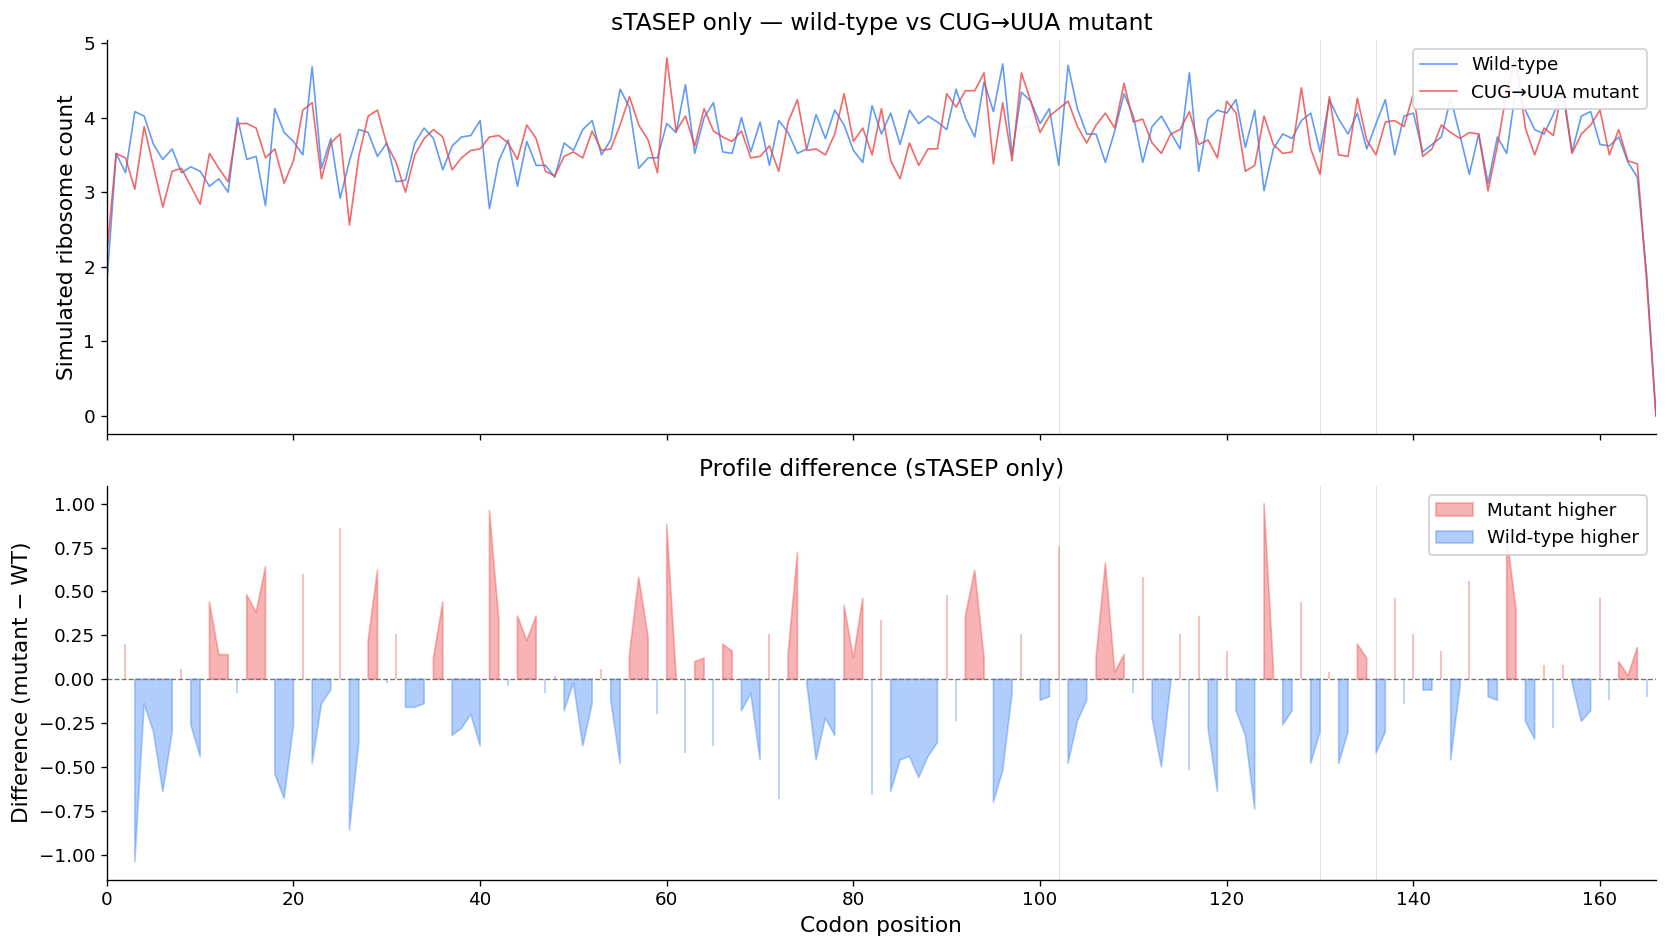


Gray vertical lines mark the 3 mutated codon positions.


In [26]:
# sTASEP simulation only (no Mamba polisher)
wt_raw = predictor_ipsc.predict(wt_seq, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]
mut_raw = predictor_ipsc.predict(mut_seq, task="riboseq", use_polisher=False, n_stasep_runs=50)[0]

x_syn = np.arange(len(wt_raw))
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(x_syn, wt_raw, color="#3b82f6", linewidth=1.0, label="Wild-type", alpha=0.8)
axes[0].plot(x_syn, mut_raw, color="#ef4444", linewidth=1.0, label="CUG→UUA mutant", alpha=0.8)
for pos in mut_positions:
    axes[0].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[0].set_ylabel("Simulated ribosome count")
axes[0].set_title("sTASEP only — wild-type vs CUG→UUA mutant")
axes[0].legend(loc="upper right", framealpha=0.9)
axes[0].set_xlim(0, len(x_syn) - 1)
axes[0].spines[["top", "right"]].set_visible(False)

diff_raw = mut_raw - wt_raw
axes[1].fill_between(x_syn, diff_raw, where=(diff_raw > 0), color="#ef4444", alpha=0.4, label="Mutant higher")
axes[1].fill_between(x_syn, diff_raw, where=(diff_raw < 0), color="#3b82f6", alpha=0.4, label="Wild-type higher")
axes[1].axhline(0, color="#737373", linewidth=0.8, linestyle="--")
for pos in mut_positions:
    axes[1].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[1].set_ylabel("Difference (mutant − WT)")
axes[1].set_xlabel("Codon position")
axes[1].set_title("Profile difference (sTASEP only)")
axes[1].legend(loc="upper right", framealpha=0.9)
axes[1].set_xlim(0, len(x_syn) - 1)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()
print(f"\nGray vertical lines mark the {len(mut_positions)} mutated codon positions.")

#### sTASEP + Mamba polisher

The same sTASEP trajectories are refined by the **Mamba polisher**. **Translation efficiency** uses the neural TE head (full path).

Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...


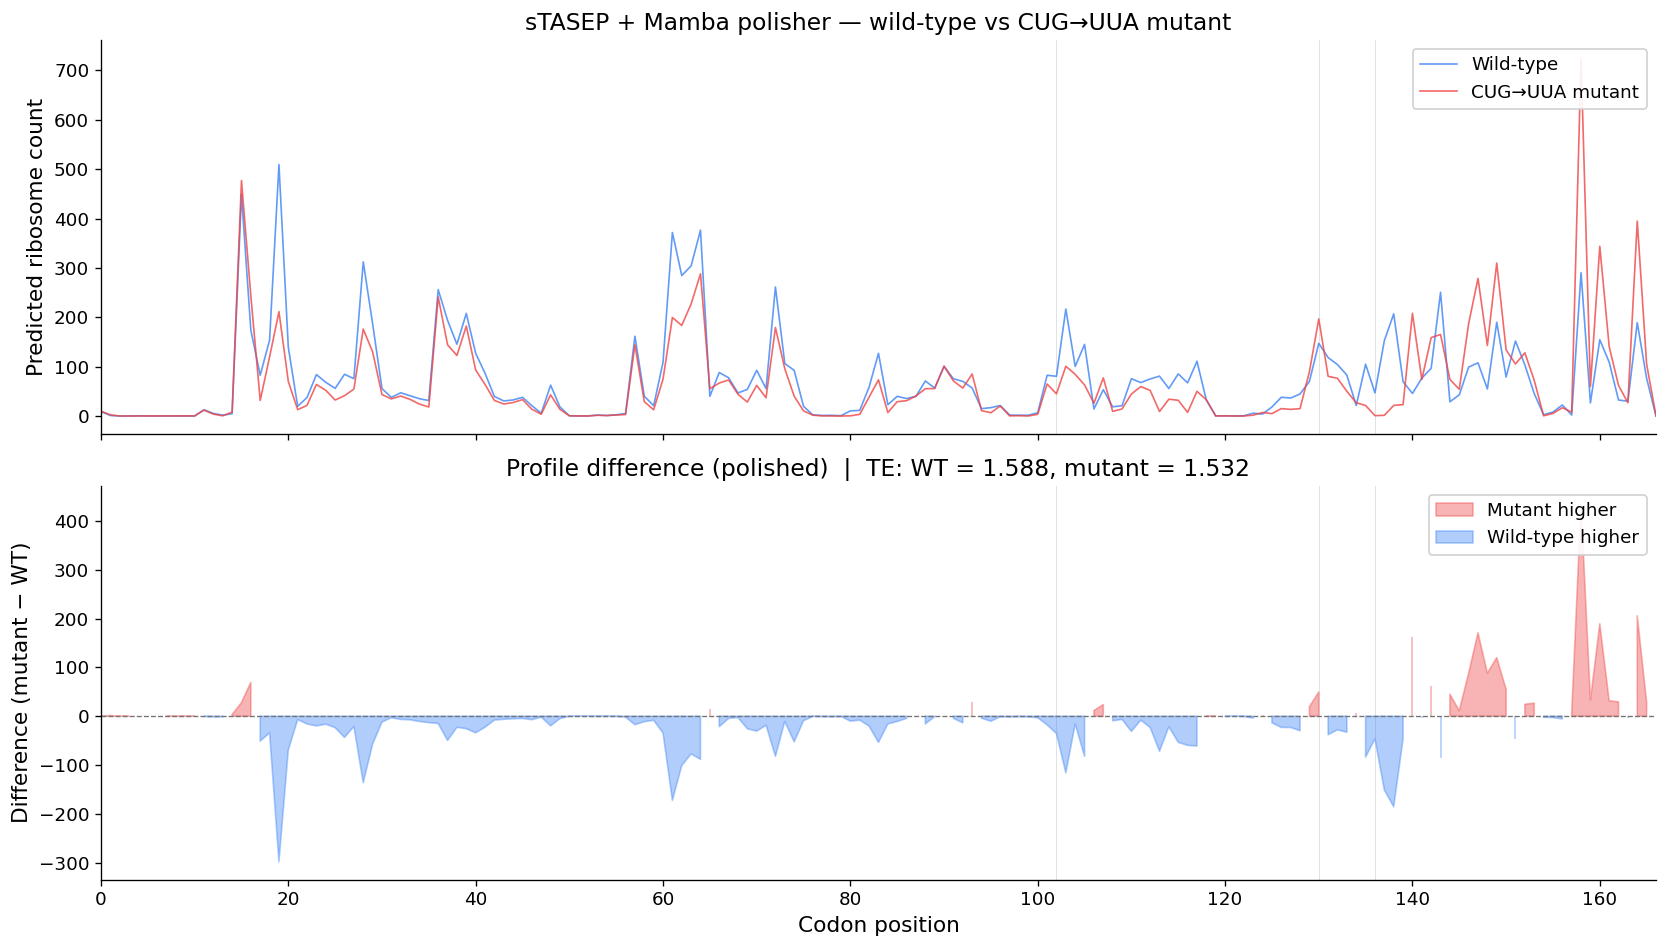

In [27]:
# Polished riboseq profiles + TE
wt_profile = predictor_ipsc.predict(wt_seq, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]
mut_profile = predictor_ipsc.predict(mut_seq, task="riboseq", use_polisher=True, n_stasep_runs=50)[0]

wt_te = predictor_ipsc.predict(wt_seq, task="te", n_stasep_runs=50)[0]
mut_te = predictor_ipsc.predict(mut_seq, task="te", n_stasep_runs=50)[0]

x_pol = np.arange(len(wt_profile))
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(x_pol, wt_profile, color="#3b82f6", linewidth=1.0, label="Wild-type", alpha=0.8)
axes[0].plot(x_pol, mut_profile, color="#ef4444", linewidth=1.0, label="CUG→UUA mutant", alpha=0.8)
for pos in mut_positions:
    axes[0].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[0].set_ylabel("Predicted ribosome count")
axes[0].set_title("sTASEP + Mamba polisher — wild-type vs CUG→UUA mutant")
axes[0].legend(loc="upper right", framealpha=0.9)
axes[0].set_xlim(0, len(x_pol) - 1)
axes[0].spines[["top", "right"]].set_visible(False)

diff_pol = mut_profile - wt_profile
axes[1].fill_between(x_pol, diff_pol, where=(diff_pol > 0), color="#ef4444", alpha=0.4, label="Mutant higher")
axes[1].fill_between(x_pol, diff_pol, where=(diff_pol < 0), color="#3b82f6", alpha=0.4, label="Wild-type higher")
axes[1].axhline(0, color="#737373", linewidth=0.8, linestyle="--")
for pos in mut_positions:
    axes[1].axvline(pos, color="#d4d4d4", linewidth=0.4, zorder=0)
axes[1].set_ylabel("Difference (mutant − WT)")
axes[1].set_xlabel("Codon position")
axes[1].set_title(f"Profile difference (polished)  |  TE: WT = {wt_te:.3f}, mutant = {mut_te:.3f}")
axes[1].legend(loc="upper right", framealpha=0.9)
axes[1].set_xlim(0, len(x_pol) - 1)
axes[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

### sTASEP vs polisher (overlay)

The two panels above use different vertical scales. Here, **sTASEP-only** and **polished** curves are **normalized to sum to 1** so you can compare shape on the same axes (run the two code cells above first so `wt_raw` / `mut_raw` / `wt_profile` / `mut_profile` exist).


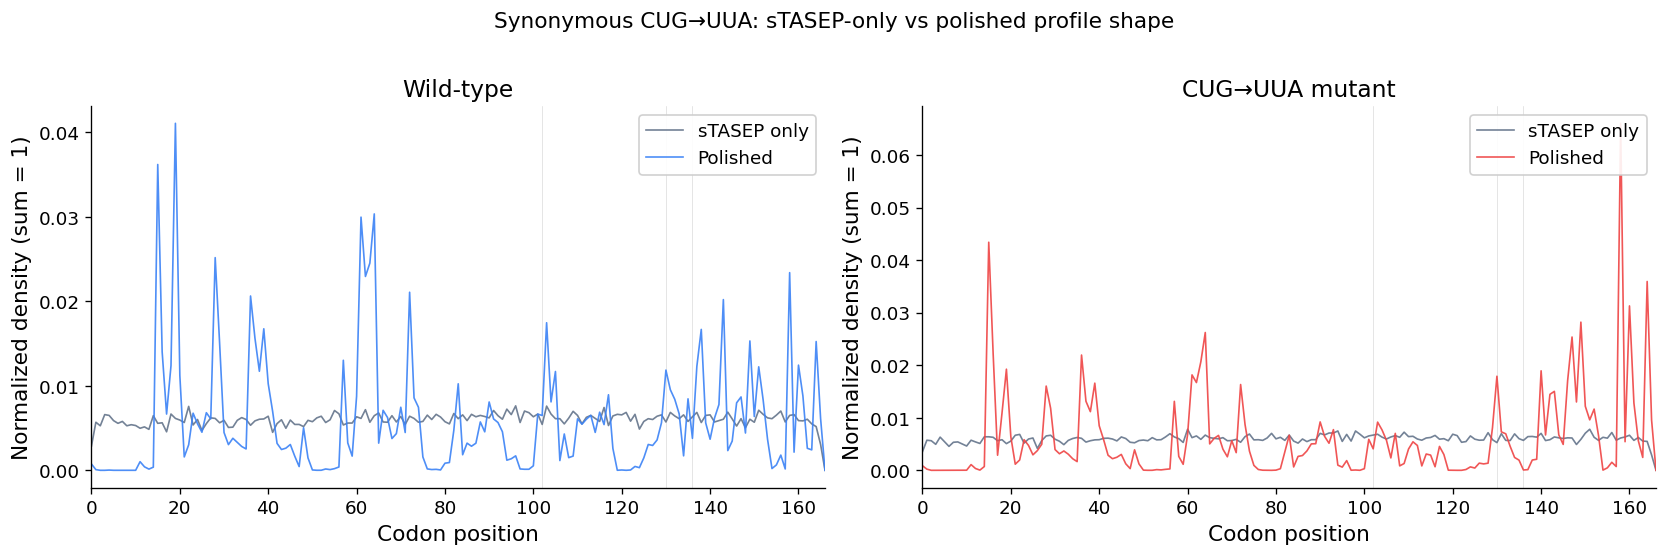

In [28]:
# Overlay sTASEP-only vs polished (requires predictions from the cells above)
def _unit_area(y):
    y = np.asarray(y, dtype=float)
    return y / (y.sum() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

for ax, raw, pol, title, pol_color in (
    (axes[0], wt_raw, wt_profile, "Wild-type", "#3b82f6"),
    (axes[1], mut_raw, mut_profile, "CUG→UUA mutant", "#ef4444"),
):
    xv = np.arange(len(raw))
    ax.plot(xv, _unit_area(raw), color="#64748b", linewidth=1.0, label="sTASEP only", alpha=0.9)
    ax.plot(xv, _unit_area(pol), color=pol_color, linewidth=1.0, label="Polished", alpha=0.9)
    for pos in mut_positions:
        ax.axvline(pos, color="#d4d4d4", linewidth=0.35, zorder=0)
    ax.set_title(title)
    ax.set_xlabel("Codon position")
    ax.set_ylabel("Normalized density (sum = 1)")
    ax.set_xlim(0, len(xv) - 1)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Synonymous CUG→UUA: sTASEP-only vs polished profile shape", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


---
## 10. sTASEP Parameter Sensitivity

The sTASEP simulation has two key user-controllable parameters:

- **`init_p`** — ribosome initiation probability. Higher values mean more ribosomes attempt to load onto the transcript per time step.
- **`n_stasep_runs`** — number of independent simulation replicas averaged together. More runs reduce stochastic noise.

Understanding how these parameters affect the output helps calibrate predictions and assess confidence.

Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.001)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.005)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.02)...
Running sTASEP simulation for 1 sequences with 30 runs per sequence (init_p=0.05)...


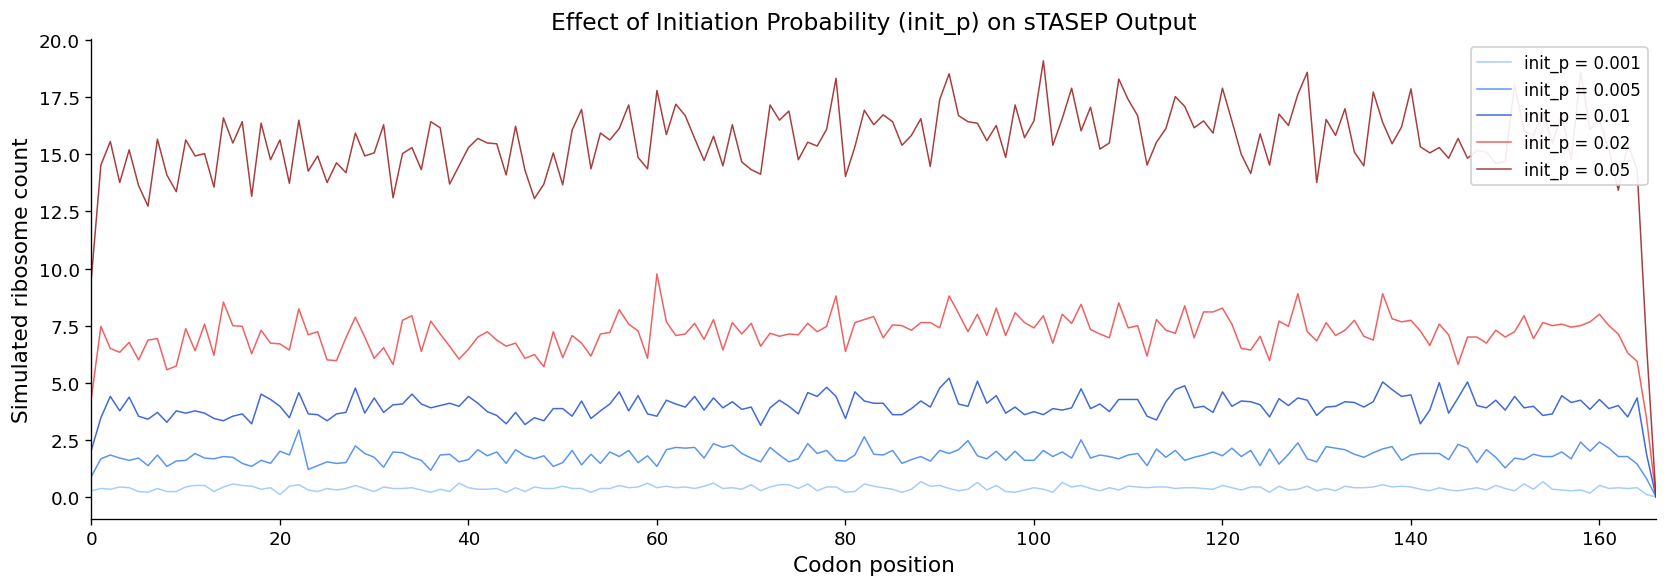

In [29]:
# Effect of init_p on simulation output (sTASEP only, no polisher)
plot_seq = demo_cds_seq
x_plot = np.arange(demo_n_codons)
init_p_values = [0.001, 0.005, 0.01, 0.02, 0.05]
init_p_colors = ["#93c5fd", "#3b82f6", "#1d4ed8", "#ef4444", "#991b1b"]

fig, ax = plt.subplots(figsize=(14, 5))
for ip, color in zip(init_p_values, init_p_colors):
    pred = predictor_ipsc.predict(
        plot_seq, task="riboseq", use_polisher=False, n_stasep_runs=30, init_p=ip
    )[0]
    ax.plot(x_plot, pred, color=color, linewidth=0.9, label=f"init_p = {ip}", alpha=0.85)

ax.set_xlabel("Codon position")
ax.set_ylabel("Simulated ribosome count")
ax.set_title("Effect of Initiation Probability (init_p) on sTASEP Output")
ax.legend(loc="upper right", framealpha=0.9, fontsize=10)
ax.set_xlim(0, demo_n_codons - 1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Running sTASEP simulation for 1 sequences with 1 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 5 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 10 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 50 runs per sequence (init_p=0.01)...
Running sTASEP simulation for 1 sequences with 200 runs per sequence (init_p=0.01)...


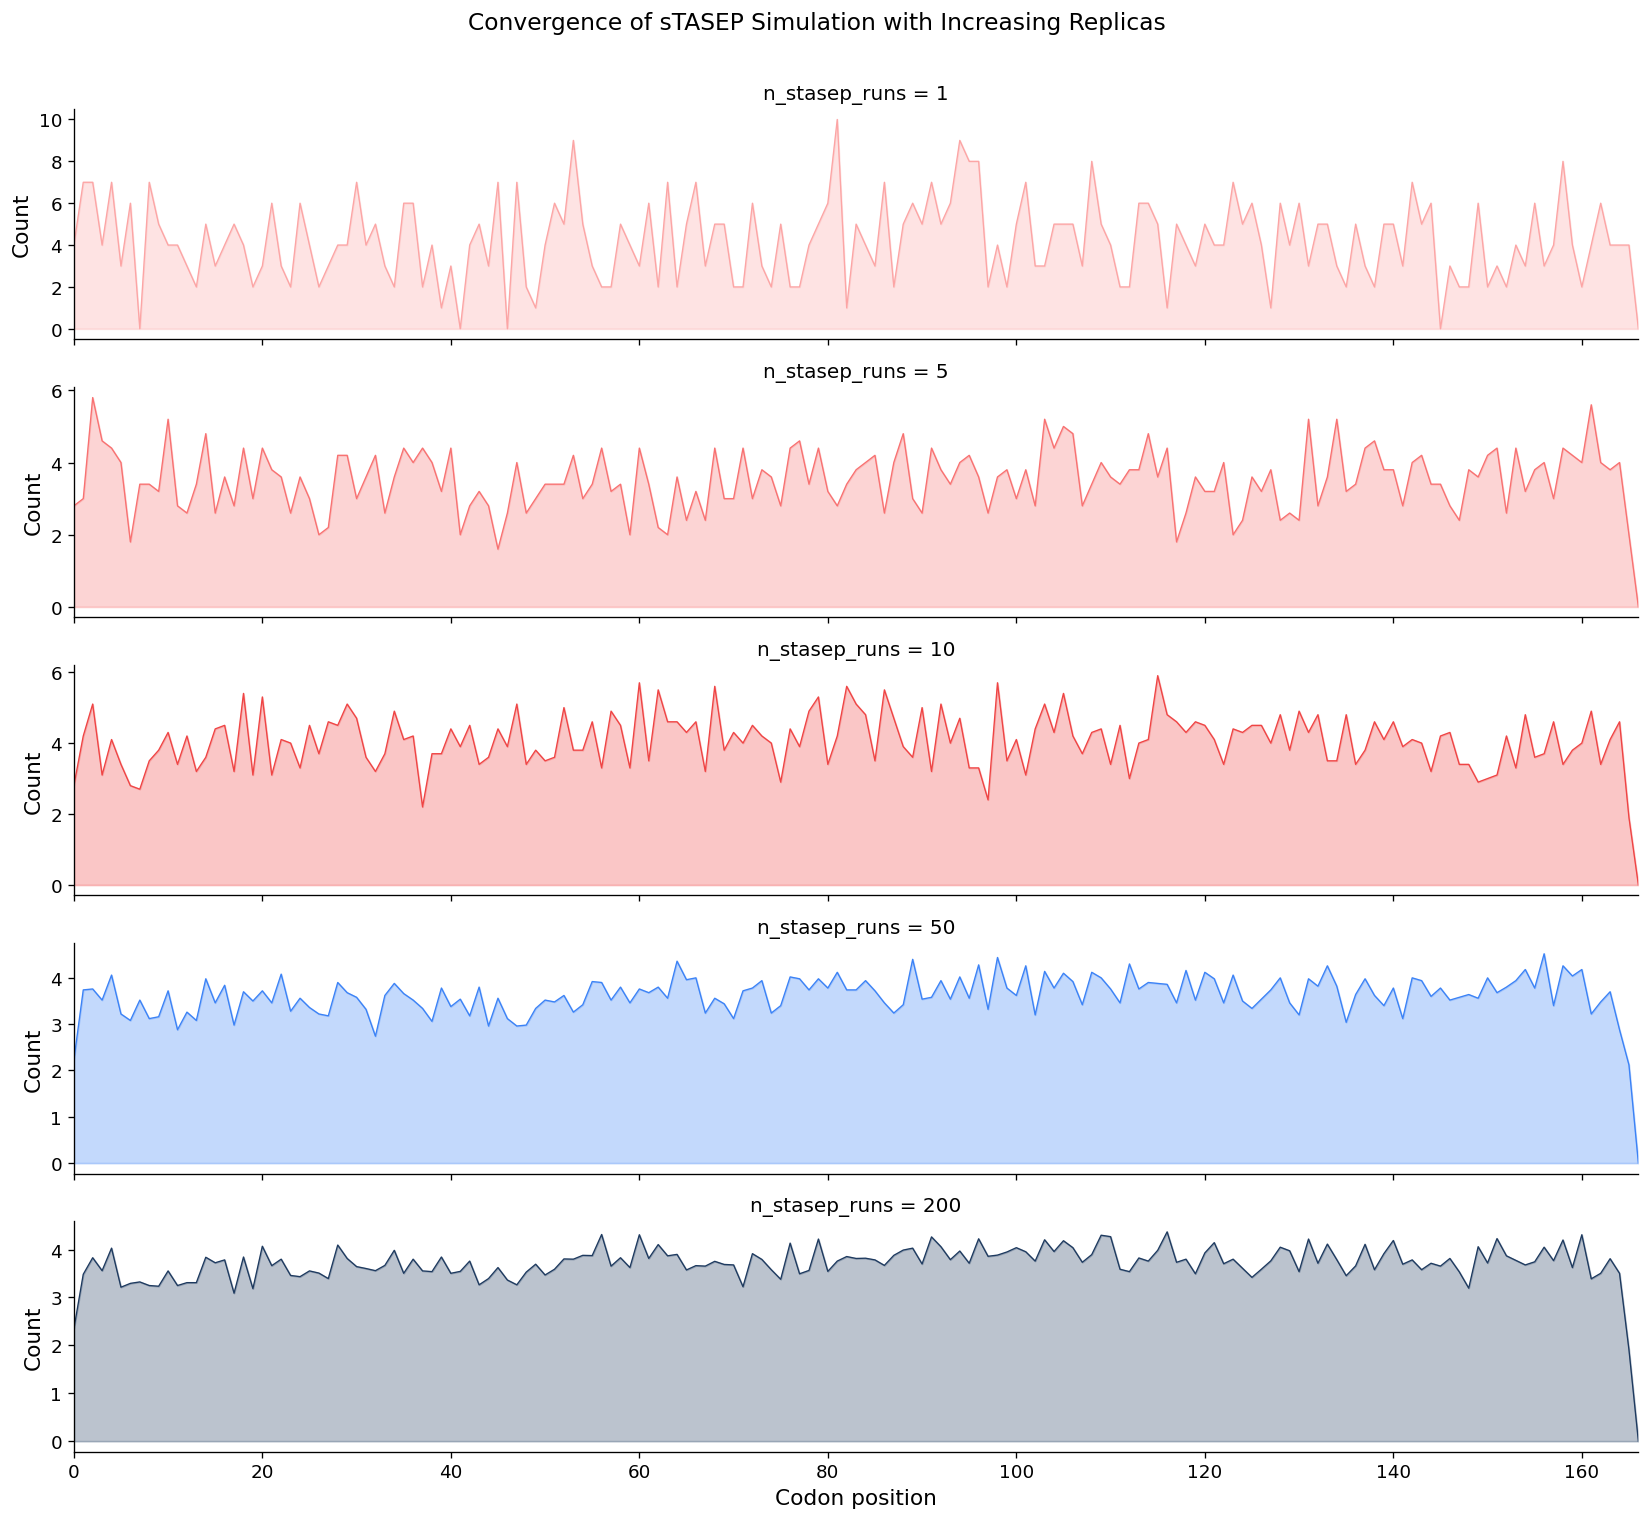

More replicas → smoother profile. The default (50–100) is a good balance.


In [30]:
# Effect of n_stasep_runs on simulation noise
plot_seq = demo_cds_seq
x_plot = np.arange(demo_n_codons)
n_runs_values = [1, 5, 10, 50, 200]
run_colors = ["#fca5a5", "#f87171", "#ef4444", "#3b82f6", "#1e3a5f"]

fig, axes = plt.subplots(len(n_runs_values), 1, figsize=(14, 2.5 * len(n_runs_values)),
                          sharex=True, sharey=False)

for ax, n_runs, color in zip(axes, n_runs_values, run_colors):
    pred = predictor_ipsc.predict(
        plot_seq, task="riboseq", use_polisher=False, n_stasep_runs=n_runs
    )[0]
    ax.fill_between(x_plot, pred, alpha=0.3, color=color)
    ax.plot(x_plot, pred, color=color, linewidth=0.8)
    ax.set_ylabel("Count")
    ax.set_title(f"n_stasep_runs = {n_runs}", fontsize=12)
    ax.set_xlim(0, demo_n_codons - 1)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Codon position")
fig.suptitle("Convergence of sTASEP Simulation with Increasing Replicas",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()
print("More replicas → smoother profile. The default (50–100) is a good balance.")

---

## Summary

| Task | Input | Output | Use case |
|------|-------|--------|----------|
| `riboseq` | CDS sequence | Per-codon ribosome counts | Identify ribosome pause sites, stalling |
| `te` | CDS (or CDS + UTRs) | Translation efficiency scalar | Compare translational output across variants |
| `protein` | CDS sequence | Protein expression scalar | Predict relative protein levels |

For more details, see the [paper](https://www.biorxiv.org/content/10.64898/2026.02.08.700508v2) and [repository](https://github.com/Kingsford-Group/seq2ribo).